# 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np

gen1 = pd.read_csv("../data/Plant_1_Generation_Data.csv")
weather1 = pd.read_csv("../data/Plant_1_Weather_Sensor_Data.csv")

# 2. Conversión de variables temporales

In [2]:
gen1["DATE_TIME"] = pd.to_datetime(gen1["DATE_TIME"])
weather1["DATE_TIME"] = pd.to_datetime(weather1["DATE_TIME"])

C:\Users\maksy\AppData\Local\Temp\ipykernel_4644\3890487811.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen1["DATE_TIME"] = pd.to_datetime(gen1["DATE_TIME"])


# 3. Agregación de producción a nivel de planta

In [3]:
plant_power = (
    gen1.groupby("DATE_TIME")
    .agg({
        "AC_POWER": "sum"
    })
    .reset_index()
)

plant_power.head()

,DATE_TIME,AC_POWER
0,2020-05-15 00:00:00,0.0
1,2020-05-15 00:15:00,0.0
2,2020-05-15 00:30:00,0.0
3,2020-05-15 00:45:00,0.0
4,2020-05-15 01:00:00,0.0


In [4]:
plant_power.info()

<class 'pandas.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DATE_TIME  3158 non-null   datetime64[us]
 1   AC_POWER   3158 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 49.5 KB


In [5]:
plant_power.head()

,DATE_TIME,AC_POWER
0,2020-05-15 00:00:00,0.0
1,2020-05-15 00:15:00,0.0
2,2020-05-15 00:30:00,0.0
3,2020-05-15 00:45:00,0.0
4,2020-05-15 01:00:00,0.0


# 4. Integración de datos meteorológicos

In [6]:
dataset = pd.merge(
    plant_power,
    weather1,
    on="DATE_TIME",
    how="inner"
)

dataset.head()

,DATE_TIME,AC_POWER,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3157 non-null   datetime64[us]
 1   AC_POWER             3157 non-null   float64       
 2   PLANT_ID             3157 non-null   int64         
 3   SOURCE_KEY           3157 non-null   str           
 4   AMBIENT_TEMPERATURE  3157 non-null   float64       
 5   MODULE_TEMPERATURE   3157 non-null   float64       
 6   IRRADIATION          3157 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 172.8 KB


In [8]:
dataset.isnull().sum()

DATE_TIME              0
AC_POWER               0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

# 5. Limpieza del dataset de integración

In [9]:
dataset = dataset.drop(
    columns=["PLANT_ID", "SOURCE_KEY"]
)

dataset.head()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,24.621525,22.165423,0.0


In [10]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3157 non-null   datetime64[us]
 1   AC_POWER             3157 non-null   float64       
 2   AMBIENT_TEMPERATURE  3157 non-null   float64       
 3   MODULE_TEMPERATURE   3157 non-null   float64       
 4   IRRADIATION          3157 non-null   float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 123.4 KB


In [11]:
dataset.describe()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3157,3157.000000,3157.000000,3157.000000,3157.000000
mean,2020-06-01 06:41:41.298701,6704.830534,25.560257,31.175453,0.230103
min,2020-05-15 00:00:00,0.000000,20.398505,18.140415,0.000000
25%,2020-05-23 23:15:00,0.000000,22.739895,21.130249,0.000000
50%,2020-06-01 12:30:00,814.880357,24.680324,24.801971,0.027748
75%,2020-06-09 18:00:00,13752.112500,27.941221,41.449481,0.451576
max,2020-06-17 23:45:00,29150.212499,35.252486,65.545714,1.221652
std,NaN,8604.217954,3.351059,12.272685,0.301348


In [12]:
(dataset["IRRADIATION"] == 0).sum()

np.int64(1403)

In [13]:
(
    (dataset["IRRADIATION"] == 0) &
    (dataset["AC_POWER"] == 0)
).sum()

np.int64(1403)

# 6. Verificación del dataset resultante

In [14]:
dataset["HOUR"] = dataset["DATE_TIME"].dt.hour

dataset["DAY"] = dataset["DATE_TIME"].dt.day

dataset["MONTH"] = dataset["DATE_TIME"].dt.month

In [15]:
dataset.head()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH
0,2020-05-15 00:00:00,0.0,25.184316,22.857507,0.0,0,15,5
1,2020-05-15 00:15:00,0.0,25.084589,22.761668,0.0,0,15,5
2,2020-05-15 00:30:00,0.0,24.935753,22.592306,0.0,0,15,5
3,2020-05-15 00:45:00,0.0,24.846130,22.360852,0.0,0,15,5
4,2020-05-15 01:00:00,0.0,24.621525,22.165423,0.0,1,15,5


In [16]:
dataset.corr(numeric_only=True)

,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH
AC_POWER,1.000000,0.725879,0.961011,0.995864,0.017323,0.031099,-0.033504
AMBIENT_TEMPERATURE,0.725879,1.000000,0.853162,0.721839,0.324166,0.198881,-0.252341
MODULE_TEMPERATURE,0.961011,0.853162,1.000000,0.961422,0.102481,0.102364,-0.117463
IRRADIATION,0.995864,0.721839,0.961422,1.000000,0.014755,0.036699,-0.041330
HOUR,0.017323,0.324166,0.102481,0.014755,1.000000,0.017958,-0.018198
DAY,0.031099,0.198881,0.102364,0.036699,0.017958,1.000000,-0.818938
MONTH,-0.033504,-0.252341,-0.117463,-0.041330,-0.018198,-0.818938,1.000000


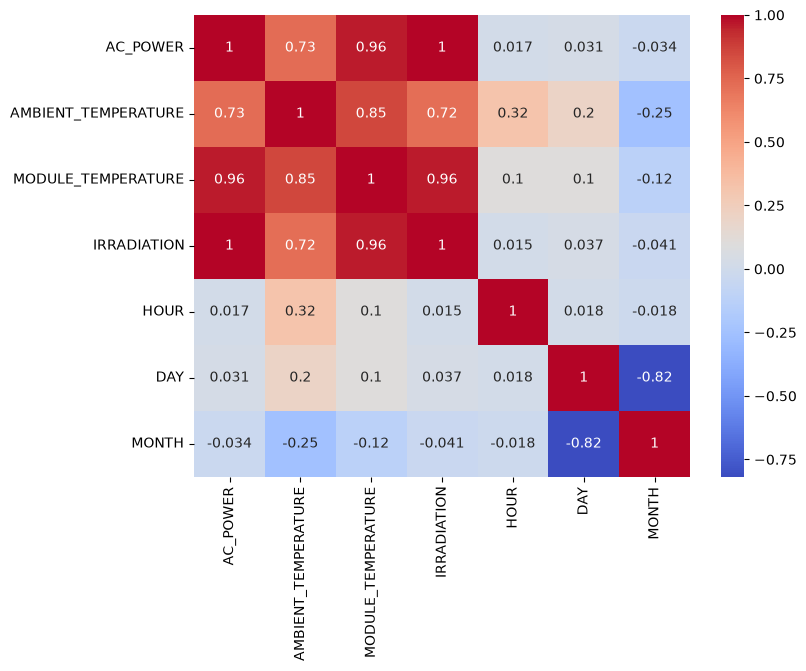

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [18]:
dataset = dataset.drop(
    columns=["DAY", "MONTH"]
)

dataset.head()

,DATE_TIME,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR
0,2020-05-15 00:00:00,0.0,25.184316,22.857507,0.0,0
1,2020-05-15 00:15:00,0.0,25.084589,22.761668,0.0,0
2,2020-05-15 00:30:00,0.0,24.935753,22.592306,0.0,0
3,2020-05-15 00:45:00,0.0,24.846130,22.360852,0.0,0
4,2020-05-15 01:00:00,0.0,24.621525,22.165423,0.0,1


In [19]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3157 non-null   datetime64[us]
 1   AC_POWER             3157 non-null   float64       
 2   AMBIENT_TEMPERATURE  3157 non-null   float64       
 3   MODULE_TEMPERATURE   3157 non-null   float64       
 4   IRRADIATION          3157 non-null   float64       
 5   HOUR                 3157 non-null   int32         
dtypes: datetime64[us](1), float64(4), int32(1)
memory usage: 135.8 KB







# 7. Exportación del dataset consolidado

In [20]:
dataset.to_csv(
    "../data/plant1_preprocessed.csv",
    index=False
)